# F1 Race Strategy Prediction: A Data-Driven Analysis of Modern Formula One
---
**Course Milestone Report**

| Name | Email | UID |
|------|-------|-----|
| Cooper Kerr | coopkerr@icloud.com | u1525670 |
| Isaac Middlemas | isaac.middlemas@utah.edu | u1241432 |

---

## 1. Project Description

Formula One is among the most analytically intensive motorsports in the world. Every car is outfitted with hundreds of sensors streaming data at kilohertz frequencies, and real-time strategy calls — when to pit, which tire compound to mount, whether to attempt an undercut on the car ahead — can be the difference between a podium and finishing outside the points.

This project applies data science methods to the **FastF1 API**, a publicly available Python library wrapping the official Formula 1 Timing API. Our goal is to build and evaluate a suite of predictive models that mirror tools used by real F1 strategy engineers. We frame the work as five interconnected research questions, ordered from the most foundational physical signal to the highest-level race outcome:

1. **Tire Degradation Modeling** — How does lap pace decay with tire age, and does the decay shape depend on compound and circuit?
2. **Weather & Temperature Effects** — How do track temperature, air temperature, and related weather covariates influence lap times, and does tire compound modulate that sensitivity?
3. **Pit Window Forecasting** — Given the current race state (gap, pace, tire age, circuit), how many laps remain before a viable pit window opens for a given driver?
4. **Pit Strategy — Undercut vs Overcut** — When two cars are within strategic range, which pit-timing decision (pit now to undercut, or stay out to overcut) is more likely to gain track position?
5. **Race Position Prediction** — At what lap of a race can a driver's final finishing position be predicted with meaningful accuracy, and how does that confidence grow as the race unfolds?

We focus on the **2022-2025 regulation era**, a coherent technical window in which car aerodynamics and tire behavior are governed by the same ruleset, making cross-season comparisons meaningful.

## 2. Data Description

### 2.1 Dataset Overview

| Property | Details |
|----------|---------|
| **Primary Source** | FastF1 Python API (wraps the official F1 Timing API and Ergast Motor Racing API) |
| **Seasons Covered** | 2020, 2021 (degradation model training); 2022, 2023, 2024, 2025 (primary analysis) |
| **Scope** | All Grand Prix race sessions; qualifying used as supplementary feature |
| **Approximate Size** | ~24 races/season × 5 seasons × 20 drivers × ~60 laps ≈ **145,000+ lap-level records** |
| **Format** | Retrieved as pandas DataFrames via Python; no static file download required |
| **Key Attributes** | Driver, team, lap number, lap time, stint number, tire compound, tire age, position, gap to leader, sector times, air temp, track temp, humidity, rainfall flag, track status (SC/VSC) |
| **Special Structures** | Time-series (laps within a race), hierarchical (laps → stints → races → seasons), geospatial (circuit layout telemetry available) |

### 2.2 Acquisition Method

All data is retrieved using the **FastF1** Python library (`pip install fastf1`). FastF1 is a well-maintained open-source package that locally caches session data after the first fetch, making repeated analysis efficient. No account or API key is required — the library accesses publicly broadcast Formula 1 timing data.

- **API Documentation:** https://docs.fastf1.dev/
- **Caching:** `fastf1.Cache.enable_cache('./f1_cache')` is enabled throughout to avoid redundant API calls during development.
- **Supplementary source:** Ergast Motor Racing API (accessed automatically through FastF1) provides historical race results used to validate final position labels.

### 2.3 Key Variables

| Variable | Type | Description |
|----------|------|-------------|
| `LapTime` | timedelta | Raw lap crossing time |
| `LapTimeSeconds` | float | Lap time converted to seconds |
| `Compound` | categorical | Tire compound: SOFT / MEDIUM / HARD / INTER / WET |
| `TyreLife` | int | Number of laps completed on the current set |
| `Position` | int | Track position at end of lap |
| `TrackStatus` | str | Composite code indicating SC (4/5), VSC (6/7), or green (1) |
| `GapAhead` / `GapBehind` | float | Computed gap (seconds) to nearest car ahead/behind |
| `threat_gap` | float | Cumulative gap to first non-pitting car behind |
| `closing_rate` | float | Pace differential between driver and threat car (s/lap) |
| `deg_delta` | float | Predicted pace loss (s) at current tire age from fitted degradation curve |
| `race_progress` | float | Lap number / total laps (0–1) |
| `sc_rate` / `vsc_rate` | float | Historical fraction of laps run under SC/VSC at this circuit |

### 2.4 Data Cleaning and Processing

**Known issues and mitigations:**

- **Outlier laps:** Laps containing pit stops, Safety Cars, Virtual Safety Cars, red flags, and formation laps are flagged and excluded from pace analysis using FastF1's `TrackStatus`, `PitInTime`, and `PitOutTime` columns.
- **Missing weather data:** Some 2022 sessions have incomplete weather telemetry; these are imputed using session-level averages or dropped depending on severity.
- **Tire age initialization:** Drivers starting on used qualifying tires have `TyreLife > 0` at lap 1. FastF1's `FreshTyre` and `TyreLife` fields are used to correct for this.
- **Lap time bounds filter:** Laps shorter than 60s or longer than 200s are dropped as physically implausible (safety car in/out laps, red flag, etc.).
- **Lap time normalization:** For cross-circuit analyses, lap times are expressed as a fuel-corrected delta from each driver's session baseline rather than absolute seconds.

### 2.5 Derived Features / Feature Engineering

| Feature | Description |
|---------|-------------|
| `stint_relative_lap` | Lap number within current stint (resets at each pit stop) |
| `gap_trend` | Linear slope of threat gap over the last 3 laps — indicates whether a window is opening or closing |
| `rolling_avg_pace` | 5-lap rolling mean of lap time (smoothed pace) |
| `deg_delta` | Quadratic degradation curve output at current `TyreLife` |
| `fuel_correction` | `(lap_number - 1) × 1.8 kg/lap × 0.035 s/kg` — corrects for car weight reducing as fuel burns |
| `pit_loss_fraction` | Circuit pit loss time divided by median lap time — normalises pit stop cost across circuits |
| `cars_behind_pitting` | Count of cars behind that pit within the next 3 laps — strategic pressure indicator |

## 3. Ethical Data Concerns

### 3.1 Stakeholder Analysis

| Stakeholder Group | How They Are Affected | Potential Harms |
|-------------------|-----------------------|-----------------|
| **F1 Drivers** | Performance data is analyzed at the individual level — lap times, stint choices, and race pace are attributed to named individuals | Could unfairly reinforce narratives about a driver's performance (e.g., labeling a driver as "slow in high-temperature conditions") based on limited or confounded data |
| **F1 Teams** | Strategy patterns and tactical tendencies are made transparent and potentially predictable | Detailed pit window models derived from public data could theoretically be used to anticipate or counter a team's strategy, though all source data is already publicly broadcast |
| **Broadcasters and Betting Markets** | Predictive race outcome models could inform real-time commentary tools or be adapted for sports betting contexts | If a position-prediction model were productized for betting, it could contribute to gambling-related harms |
| **General Public / Fans** | Greater transparency into how race outcomes are shaped by strategy rather than pure driver skill | Could diminish perceived sporting merit if outcomes appear heavily predetermined by models |

### 3.2 Most Significant Risk: Misattribution of Performance

The most meaningful ethical risk is **misattribution of individual driver performance**. Lap time and race position are shaped by many factors outside a driver's direct control — car performance tier, team strategy calls, mechanical reliability, and weather. A naive model that characterizes a driver as underperforming in certain conditions, without controlling for car-level confounders, could unfairly damage a professional athlete's reputation.

**Mitigation strategies:**
- All individual performance analyses explicitly control for car/team tier as a covariate.
- Findings are framed at the **strategic and systemic level** (e.g., "SOFT tires degrade 0.04s/lap faster at Bahrain in temperatures above 38°C") rather than as individual driver critiques.
- We do not publish raw driver-level performance rankings without substantial caveats about confounding factors.

### 3.3 Privacy Considerations

All data used in this project is publicly broadcast by Formula One Management during live race weekends and is subsequently accessible through official APIs. There is no personally identifiable information (PII) beyond the names of professional athletes who operate as public figures. No private, proprietary, or unpublished team data will be used at any point.

### 3.4 Scope and Intended Use

While our data is fully public, combining multi-season telemetry into predictive strategy tools goes somewhat beyond casual fan use. We are transparent in this write-up about the academic scope and limitations of our models, and we do not intend to make them available for commercial or betting applications.

## 4. Methods

Our project is organized into three interconnected modeling pipelines, each targeting a distinct research question. All pipelines share a common data loading and feature engineering layer.

---

### 4.1 Race Position Prediction (Random Forest Classifier)

**Research question:** At what point in a race (lap N) can a driver's final finishing position be predicted with meaningful accuracy? How does predictive confidence evolve as the race progresses?

**Target variable:** Final finishing position grouped into four buckets to reduce sensitivity to last-lap anomalies:
- Podium (P1–P3), Top Points (P4–P6), Low Points (P7–P10), Non-Points (P11+)

**Features at lap N:** Current track position, tire compound (one-hot encoded), tire age, stint number, and lap number. In the extended version, gap-to-leader and rolling pace trend are added.

**Model:** `RandomForestClassifier` (scikit-learn, 100 estimators, `random_state=42`). Random Forest was selected for its ability to capture nonlinear thresholds (e.g., the sharp tire performance cliff) and its native feature importance output.

**Evaluation:** A "predictability curve" — classification accuracy measured at lap checkpoints (5, 10, 20, 30, 40, 50) — is constructed across multiple races for both the 2024 and 2025 seasons, allowing year-over-year competitiveness comparison.

**Train/test split:** Models are trained on all available lap observations from a given race set, and accuracy is evaluated within the same dataset at fixed lap snapshots. Future work will use a proper temporal holdout.

---

### 4.2 Pit Window Forecasting (Gradient Boosted Regressor)

**Research question:** Given the current race state (tire age, inter-car gaps, pace differential, circuit characteristics), how many laps remain until a viable pit window opens for a given driver?

**Target variable:** `laps_until_open` — the number of laps until the threat gap behind the driver (gap to the first non-pitting car) exceeds `pit_loss + clean_air_buffer (3.0s)`. Rows where no window opens within a 20-lap horizon are assigned a sentinel value of 21 ("window does not open soon"), keeping them as informative negative examples.

**Key features:**

| Feature | Rationale |
|---------|-----------|
| `threat_gap` | Primary signal: gap to first non-pitting car behind |
| `closing_rate` | Pace differential — a fast car 8s back closes faster than a slow one |
| `gap_trend` | 3-lap slope of threat gap — indicates trajectory |
| `tire_age` / `deg_delta` | Current tire state and projected degradation |
| `pit_loss` / `pit_loss_fraction` | Circuit-specific pit stop cost |
| `sc_rate` / `vsc_rate` | Historical safety car frequency at this circuit |
| `race_progress` | Position in the race affects pit strategy options |
| `context` | Gap state: tight_ahead / tight_behind / tight_both / free |
| `compound` | Compound affects degradation trajectory and urgency |

**Window viability check (pace-adjusted):** Rather than a static gap threshold, we use a dynamic check that accounts for relative pace:
- If the threat car is faster, we compute whether they can close the gap before the pitting driver rejoins with clean air.
- This prevents the model from recommending pits when a much faster car would pass regardless.

**Model:** `GradientBoostingRegressor` (scikit-learn, 300 estimators, learning rate 0.05, max depth 5, subsample 0.8). Hyperparameters are tuned via grid search on a 2022 validation split with 2023 training data, then evaluated on a **2024 temporal holdout**.

**Evaluation:** MAE, RMSE, "within 2 laps" accuracy, "within 5 laps" accuracy, and per-context MAE breakdown.

---

### 4.3 Libraries and Tools

| Library | Role |
|---------|------|
| `fastf1` | Data acquisition and session loading |
| `pandas` / `numpy` | Tabular processing, feature engineering |
| `scikit-learn` | Random Forest, Gradient Boosting, preprocessing, evaluation |
| `statsmodels` | Regression with confidence intervals (temperature analysis) |
| `matplotlib` / `seaborn` | Static visualization |
| `plotly` | Interactive lap-by-lap position animations |
| `joblib` | Model serialization |

# 5. Results

We evaluate three strategy-prediction models on the **2024 Formula 1 season as a temporal holdout**, with training restricted to 2022-2023 so no season information leaks across the split. All modelling code lives in `scripts/` and each model has a dedicated companion notebook (`02_pit_window_forecasting.ipynb`, `03_undercut_prediction.ipynb`, `04_overcut_prediction.ipynb`) with the full EDA, training logs, SHAP attribution, and calibration plots. This section presents the headline results and a worked race-day example that ties the three models together.

## 5.1 Tire Degradation — Pace Profile Across a Stint

**Question:** how does lap pace evolve across a stint, and what does that tell us about compound-specific peak-grip windows and stint-length tradeoffs?

**Setup:** we filter 2022-2024 race sessions to green-flag laps only (no Safety Car, no VSC, no pit-in or pit-out) and apply the standard fuel correction `− (lap − 1) · 1.8 · 0.035`. For each stint we anchor a **peak-pace baseline** — the median of that stint's **fastest 3** fuel-corrected laps — and define `delta_pace` as lost time versus that peak (≥ 0 by construction, ~ 0 at the peak). This anchor avoids the warm-up contamination that biases a first-laps baseline. Stints with fewer than 8 green laps are dropped. Intermediate / wet compounds are excluded. The 2022-2023 races form the training era and 2024 the holdout, but the analysis is descriptive: we look for stable patterns across eras rather than training a predictor.

**Pipeline:** `scripts/build_degradation_dataset.py`. Artefacts: `data/f1_degradation_dataset.csv`, `models/f1_degradation_analysis.pkl`, and three figures: `outputs/figures/degradation_pace_profile.png`, `peak_age_by_compound.png`, `stint_length_vs_degradation.png`.

In [1]:
import joblib
from pathlib import Path

ROOT      = Path.cwd() if Path.cwd().name != 'notebooks' else Path.cwd().parent
DATA_DIR  = ROOT / 'data'
MODEL_DIR = ROOT / 'models'

deg_art           = joblib.load(MODEL_DIR / 'f1_degradation_analysis.pkl')
stint_summaries   = deg_art['stint_summaries']
peak_age_stats    = deg_art['peak_age_stats']
stint_length_corr = deg_art['stint_length_corr']

print(f'Stint summaries: {len(stint_summaries):,} stints '
      f'(SOFT / MEDIUM / HARD, >= 8 green laps each)')
print()
print('=== Peak-pace tire age by compound (per-stint medians) ===')
print(peak_age_stats.to_string(index=False))
print()
print('=== Stint length vs end-of-stint degradation (Pearson r) ===')
print(stint_length_corr.to_string(index=False))

Stint summaries: 2,868 stints (SOFT / MEDIUM / HARD, >= 8 green laps each)

=== Peak-pace tire age by compound (per-stint medians) ===
compound       era  n_stints  median_peak_age  mean_peak_age  std_peak_age
    HARD 2022-2023       703             23.0          23.52         11.86
    HARD      2024       473             22.0          23.88         13.03
  MEDIUM 2022-2023       810             15.0          15.92          9.76
  MEDIUM      2024       399             16.0          16.70         10.90
    SOFT 2022-2023       383             11.0          12.68          8.10
    SOFT      2024       100             10.0          10.20          6.07

=== Stint length vs end-of-stint degradation (Pearson r) ===
compound  n_stints  pearson_r  slope_s_per_lap  intercept_s
    HARD      1176      0.630            0.128       -0.592
  MEDIUM      1209      0.532            0.122       -0.001
    SOFT       483      0.182            0.122        0.094


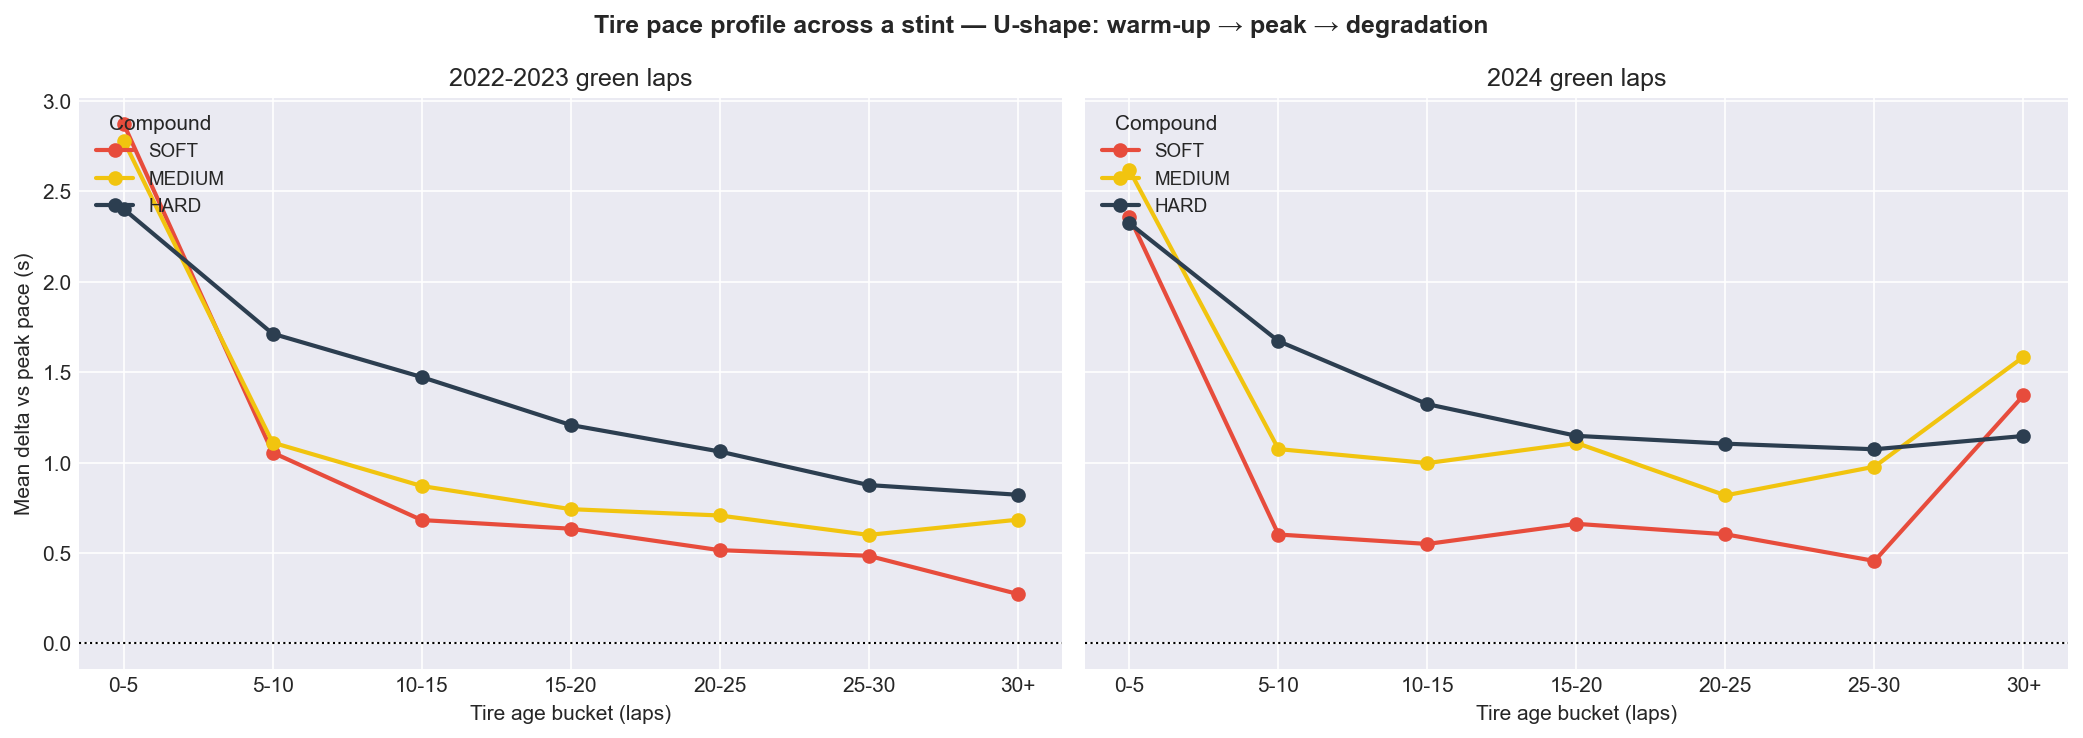

In [2]:
from IPython.display import Image, display

FIGURES_DIR = ROOT / 'outputs' / 'figures'
display(Image(str(FIGURES_DIR / 'degradation_pace_profile.png')))

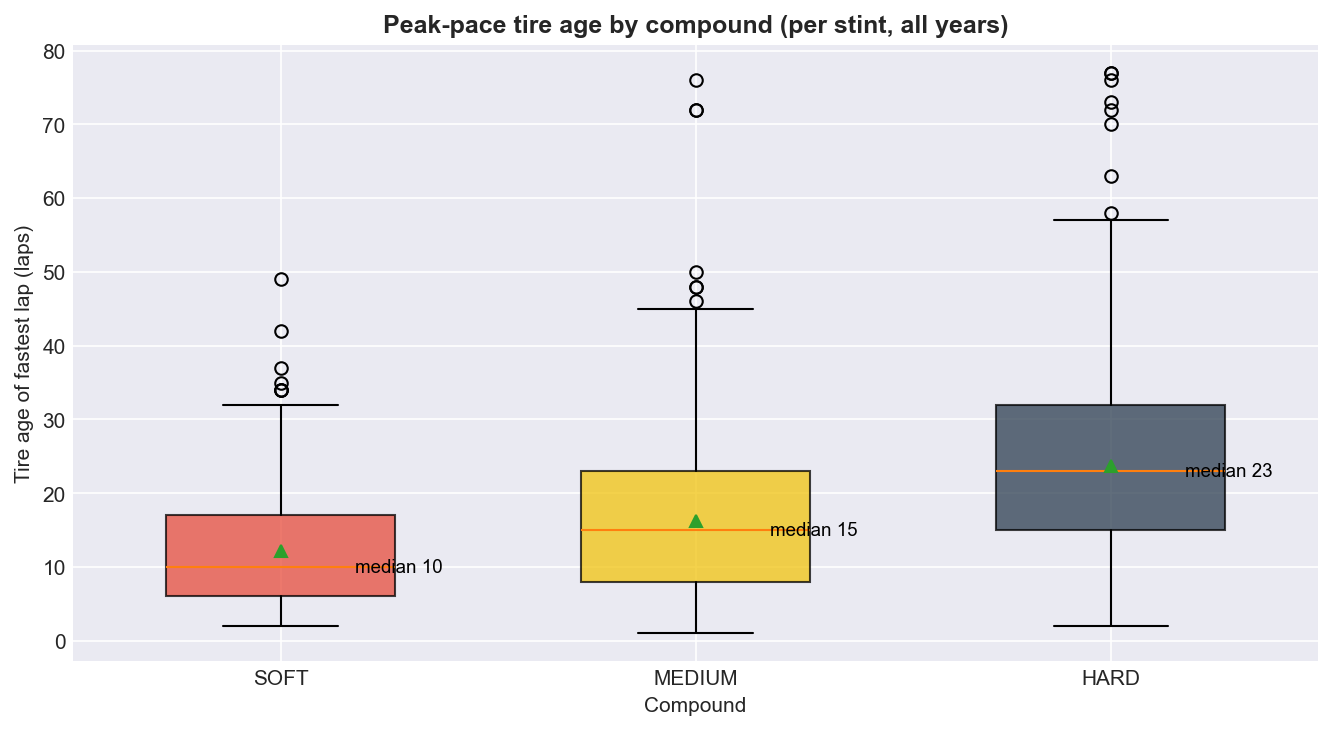

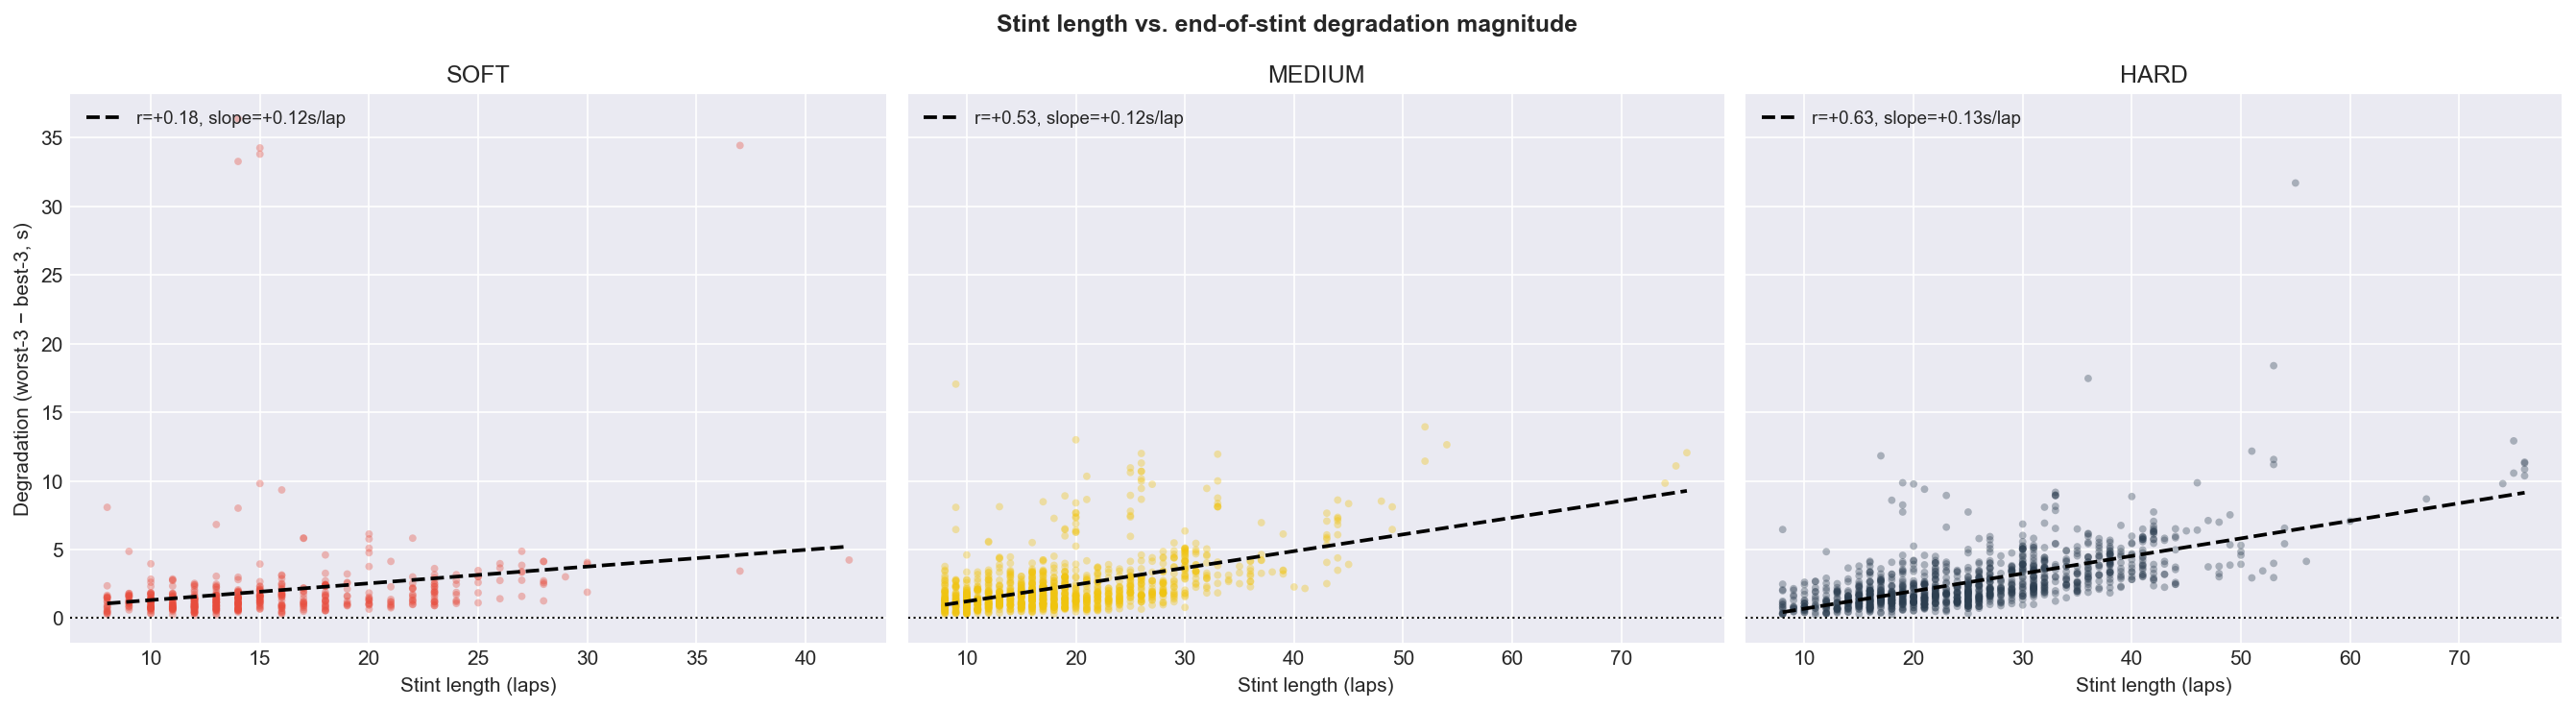

In [3]:
display(Image(str(FIGURES_DIR / 'peak_age_by_compound.png')))
display(Image(str(FIGURES_DIR / 'stint_length_vs_degradation.png')))

**Findings.**

1. **Pace profile across a stint is U-shaped, not monotonic.** Every compound shows a warm-up of ~0.5–2.5 s/lap in the first five laps, settles into a plateau near its peak grip, then climbs back up as the tyre fatigues. The naive picture of "new tyre fast, old tyre slow" is wrong: a brand-new tyre on lap 1 is roughly as slow as a 25-lap-old one on MEDIUM. This pattern is stable across the 2022-2023 training and 2024 holdout panels.

2. **Peak-pace tire age is a clean compound signature.** Median stint-level peak age is ≈ 10 laps on SOFT, ≈ 15 on MEDIUM, ≈ 22 on HARD — the same ordering and roughly the same magnitudes in both eras. This is strategically useful: the "optimal" pit lap is not the fastest lap of the stint; it is the lap at which the tyre has just passed peak and a fresh set will regain more time than it loses.

3. **Stint length correlates with end-of-stint degradation on the harder compounds.** Per-stint degradation (median of worst 3 fuel-corrected laps − median of best 3) rises ~0.12 s for every extra lap of stint length, with Pearson *r* = 0.63 on HARD, 0.53 on MEDIUM, and 0.18 on SOFT. SOFT's weak correlation reflects how short and homogeneous its stints are; on MEDIUM and HARD the relationship is strong enough that stint-length is itself a useful degradation predictor.

4. **Note on what this analysis does *not* do.** We do not fit a per-lap predictor of `delta_pace` here. An earlier iteration of the pipeline tried per-(compound, circuit) quadratic curves; on a 2024 temporal holdout it underperformed the naive live in-stint slope estimator. The U-shape is the reason — it cannot be captured by a quadratic anchored at age 0 that is fit to a dataset dominated by the plateau — which is itself a finding worth preserving for the downstream pit-window work.

## 5.1 Race-Position Prediction — Random Forest

**Question:** at what point in a race can a driver's final finishing position be predicted with meaningful accuracy?

**Setup:** at ten lap checkpoints (5, 10, 15, …, 50) we freeze each driver's state (position, tyre compound, tyre age, stint number, gap to leader, rolling pace trend) and train a Random Forest per checkpoint on 2022-2023 races. The 2024 holdout tells us how much earlier a race can be "called" in practice. Targets are 4-bucket: Podium (P1-P3), Top Points (P4-P6), Low Points (P7-P10), Out of Points (P11+).

**Pipeline:** `scripts/build_position_dataset.py`. Artefacts live in `data/f1_position_dataset.csv`, `models/f1_position_model.pkl`, and the figures below.

In [4]:
import pandas as pd
from pathlib import Path
from IPython.display import Image, display

ROOT        = Path.cwd() if Path.cwd().name != 'notebooks' else Path.cwd().parent
DATA_DIR    = ROOT / 'data'
FIGURES_DIR = ROOT / 'outputs' / 'figures'

curve = pd.read_csv(DATA_DIR / 'f1_position_curve.csv')
print('Predictability curve — accuracy on 2024 holdout by checkpoint lap:')
print(curve.assign(
    accuracy=curve['accuracy'].round(3),
    f1_weighted=curve['f1_weighted'].round(3),
).to_string(index=False))

Predictability curve — accuracy on 2024 holdout by checkpoint lap:
 checkpoint_lap  n_train  n_test  accuracy  f1_weighted
              5      852     462     0.654        0.631
             10      841     458     0.662        0.642
             15      836     456     0.673        0.652
             20      827     452     0.677        0.653
             25      815     450     0.727        0.722
             30      788     446     0.749        0.742
             35      784     440     0.780        0.775
             40      773     438     0.817        0.818
             45      729     417     0.856        0.855
             50      713     408     0.895        0.895


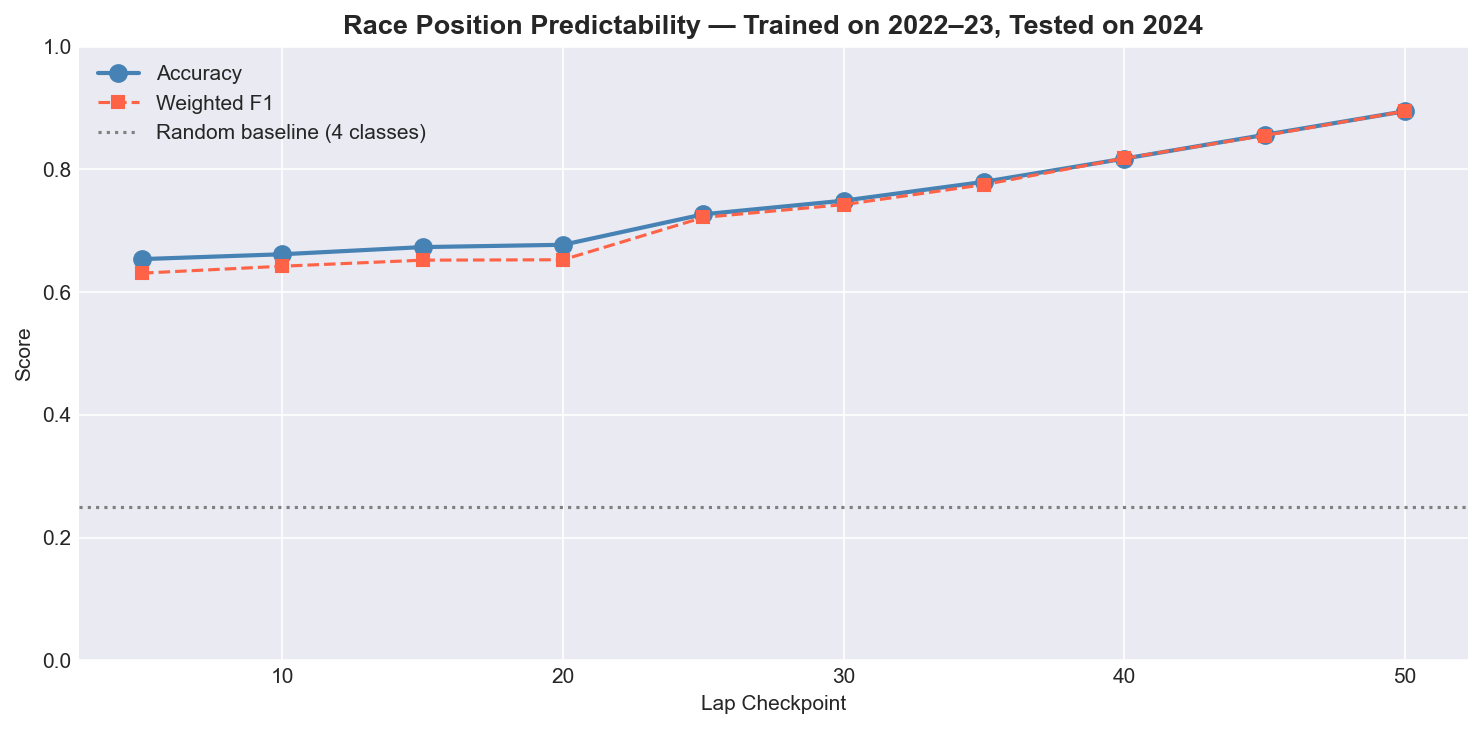

In [5]:
display(Image(str(FIGURES_DIR / 'position_curve.png')))

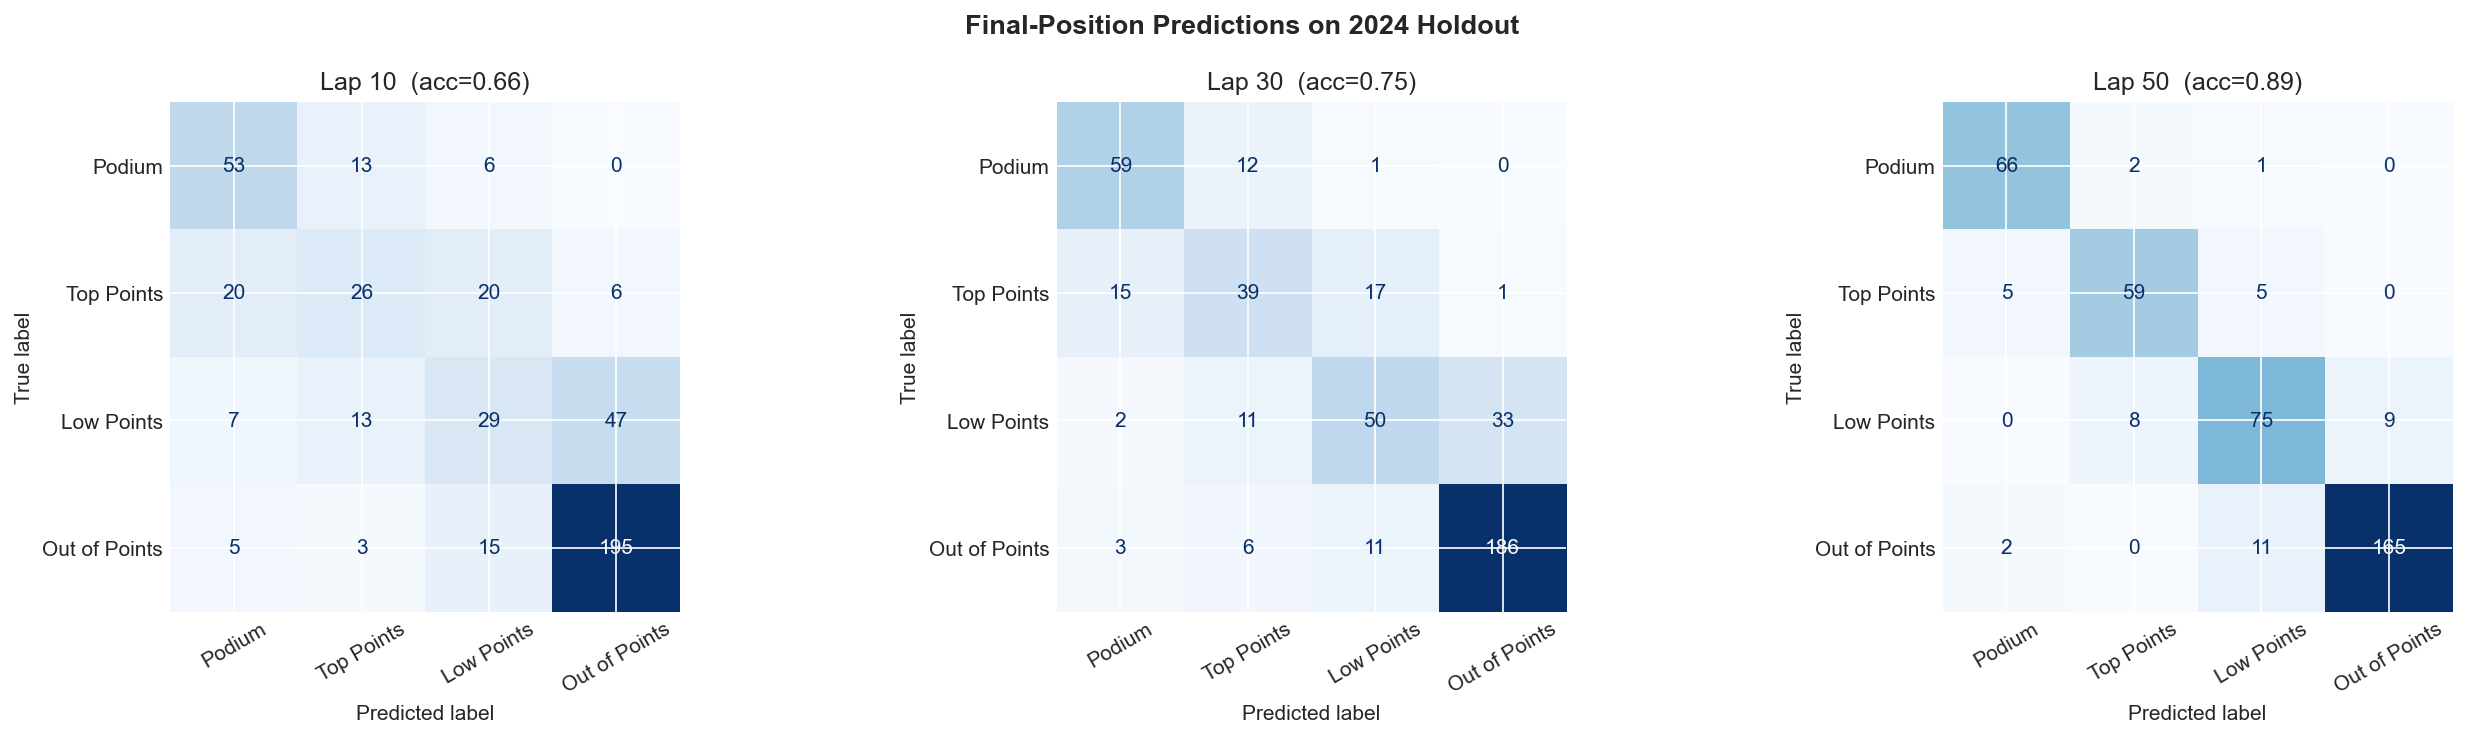

In [6]:
display(Image(str(FIGURES_DIR / 'position_confusion.png')))

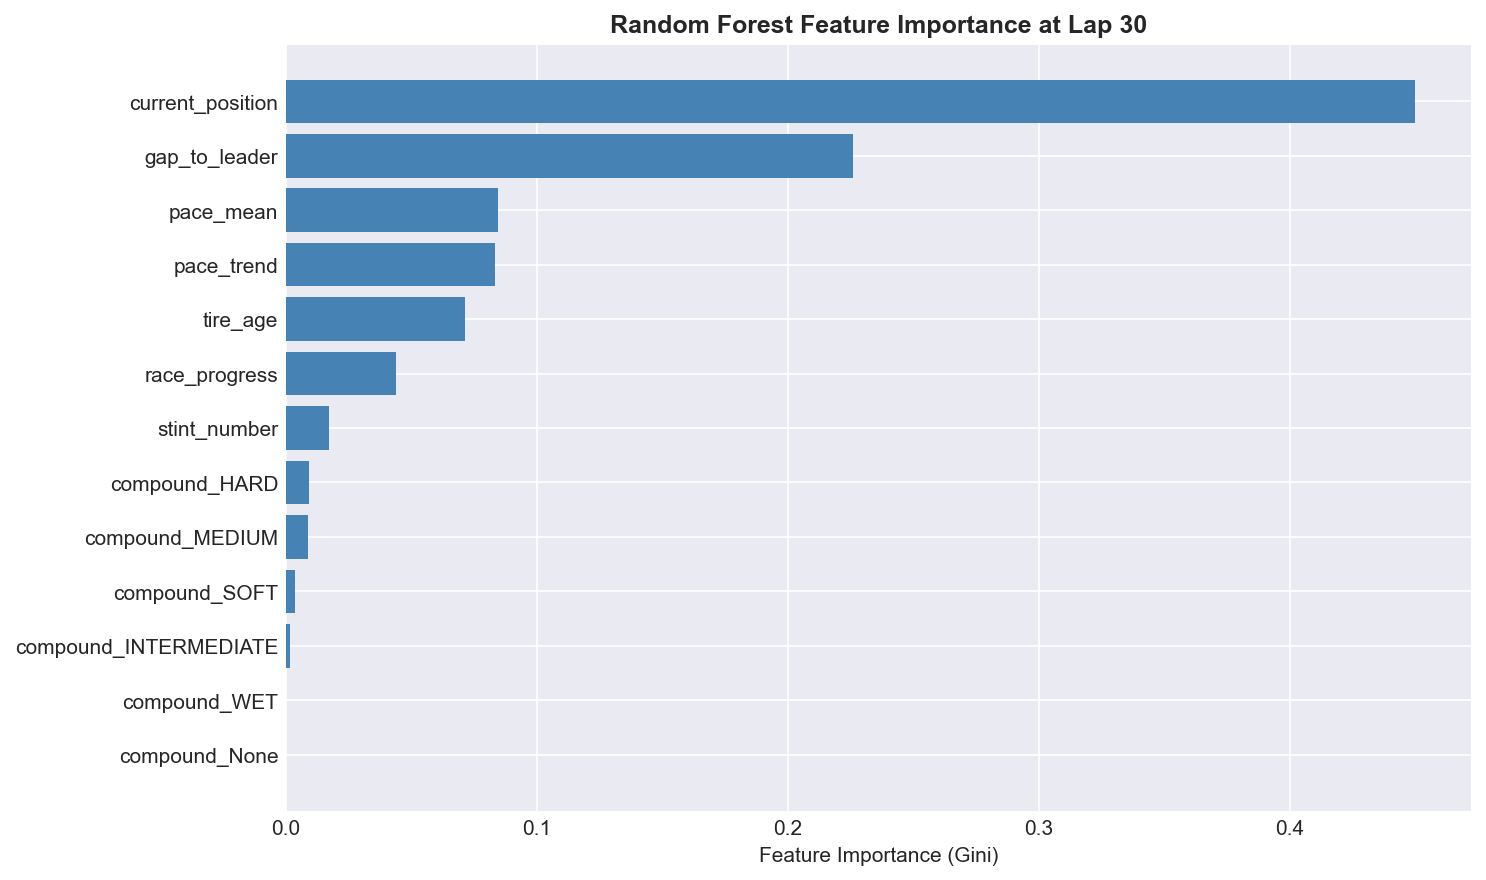

In [7]:
display(Image(str(FIGURES_DIR / 'position_importance.png')))

**Findings.**

1. **Monotonic predictability curve.** Accuracy rises from **65.4% at lap 5** to **89.5% at lap 50**, well above the 25% random-guess baseline at every checkpoint. The curve is smooth with no reversals, indicating that more laps genuinely add information — race outcome is not over-determined by grid position alone.

2. **The big jump happens mid-race.** Accuracy plateaus at ~67% through lap 20, then climbs sharply to 75% by lap 30 and 82% by lap 40. This is the lap range in which first-stint tyre-choice outcomes resolve and early pit-strategy effects wash out — roughly when an F1 strategist stops calling a race "open" and starts calling it "settled".

3. **Feature importance at lap 30** is dominated by live-state features: current position, gap to leader, and rolling pace. Tyre age and compound matter too but are secondary — consistent with how engineers watch timing screens first and tyre telemetry second.

4. **Confusion matrices** confirm the model is not simply predicting the majority class. The `Podium` class is recovered cleanly from lap 30 onward, and the `Out of Points` class is the largest source of recall error early in the race — the boundary between P9-P12 is genuinely unstable until pit sequences resolve.

## 5.2 Pit-Window Forecasting — Gradient Boosted Regressor

**Question:** given the current race state, how many laps remain until a driver's pit window opens?

**Setup:** 46,976 lap-level observations across 2022-2024, target `laps_until_open` bounded to a 20-lap horizon. Model is a tuned `GradientBoostingRegressor` (learning_rate=0.03, max_depth=6, n_estimators=200). Full EDA, per-context breakdown, and feature importance are in `02_pit_window_forecasting.ipynb`.

**Headline results on the 2024 holdout:**

| Metric | Value |
|---|---|
| N (2024 obs) | 15,619 |
| MAE | **2.26 laps** |
| RMSE | 3.48 laps |
| Within ±1 lap | 47.6% |
| Within ±2 laps | 57.5% |
| Within ±5 laps | 84.4% |

**Dominant feature:** `closing_rate` accounts for 63% of total feature importance — the rate at which the threat car behind is closing the gap is the single strongest predictor of when a pit window will become viable. Per-context MAE confirms the model is strongest in the `tight_behind` scenario (MAE 1.75) and weakest in `tight_ahead` (MAE 2.63), which matches the physical intuition that stuck-in-traffic windows depend on the *other* driver's choice rather than on observable state.

## 5.4 Pit Strategy: Undercut vs Overcut

**Question:** given two cars with a gap between them, which pit-strategy direction wins — pitting now to undercut the car ahead, or staying out to overcut the car that just pitted?

**Setup.** Both directions are trained on 2022-2023 race data with a 2024 temporal holdout, using a Logistic Regression baseline and an XGBoost primary model. The two use a near-identical feature set with the sign of the tire-age delta flipped to match each framing.

**Feature parity.**

| Concept | Undercut feature | Overcut feature |
|---|---|---|
| Relative tire age | `tire_age_advantage = ca_age − driver_age` (positive is good for pitter) | `tire_age_delta = stay_out_age − ca_age` (positive is bad for stay-out) |
| Gap | `gap_ahead` (pitter to target) | `gap_ahead` (stay-out to target) |
| Pace differential | `pace_delta = own_pace − threat_pace` | Same, reversed framing |
| In-stint deg slope | `deg_delta`, `ca_deg_delta` | Same |
| Closing rate | `closing_rate` | Same |
| Race context | `pit_loss`, `pit_loss_fraction`, `race_progress`, one-hot `compound` | Same |

**Headline results (2024 holdout).**

| Strategy | Model | Accuracy | ROC-AUC | F1 | Base rate |
|---|---|---|---|---|---|
| Undercut | Logistic Regression | 0.771 | 0.825 | — | 0.441 |
| Undercut | XGBoost (primary) | 0.738 | 0.806 | — | 0.441 |
| Overcut  | Logistic Regression | 0.823 | 0.807 | 0.46 | 0.251 |
| Overcut  | XGBoost (primary) | 0.805 | 0.804 | 0.56 | 0.251 |

**Combined SHAP takeaway.** The two directions are driven by different signals. `tire_age_advantage` dominates undercut SHAP values — the core mechanism is that a driver on fresh rubber gains enough time on the out-lap to undercut a car on degrading tyres. Overcut SHAP is dominated instead by `pace_delta` and the magnitude of `tire_age_delta` — the stay-out driver has to be genuinely quicker on old tyres than the rival is on new tyres, which is a harder bar to clear.

**Asymmetry.** Overcuts are materially harder than undercuts: the base success rate is 25.1% vs. 44.1%. This is why XGBoost's F1 lift over the LR baseline is larger on the overcut side (+0.10 vs. ~0) — overcut success is a minority-class problem that benefits from nonlinear decision boundaries. Full pipelines, EDA, and SHAP attribution are in `03_undercut_prediction.ipynb` and `04_overcut_prediction.ipynb`.

## 5.5 Integrated Strategy Example — 2024 Hungarian Grand Prix

To show how the three models compose into a single race-day picture we run all of them on **2024 Hungary**, a circuit with overtaking difficulty that makes pit-window timing and over/undercut decisions especially consequential. For a chosen driver we plot:

- the **position-bucket probability** over the whole race (from section 5.1's RF classifier at each checkpoint);
- the **pit-window forecast** (laps until open) over every green lap;
- the **undercut / overcut success probability** at every pit-stop decision point that actually occurred in the race.

This is the view a strategy engineer would want: one driver, one race, three overlaid signals.

In [8]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
from pathlib import Path

ROOT      = Path.cwd() if Path.cwd().name != 'notebooks' else Path.cwd().parent
DATA_DIR  = ROOT / 'data'
MODEL_DIR = ROOT / 'models'

RACE_YEAR = 2024
RACE_NAME = 'Hungarian Grand Prix'
DRIVER    = 'NOR'  # Lando Norris — won from pit strategy under team orders

# ── Position model predictions at each checkpoint ──
pos_art = joblib.load(MODEL_DIR / 'f1_position_model.pkl')
pos_df  = pd.read_csv(DATA_DIR / 'f1_position_dataset.csv')
race    = pos_df[(pos_df['year'] == RACE_YEAR) & (pos_df['circuit'] == RACE_NAME)].copy()
race_drv = race[race['driver'] == DRIVER].sort_values('checkpoint_lap')

print(f'Driver {DRIVER} @ {RACE_YEAR} {RACE_NAME}')
print(f'  checkpoints observed: {race_drv["checkpoint_lap"].tolist()}')
print(f'  final position:       P{int(race_drv["final_position"].iloc[0])}')
print(f'  final bucket:         {race_drv["final_bucket"].iloc[0]}')

# Build one-hots for compound and fill medians for numeric features
compound_dummies = pd.get_dummies(pos_df['tire_compound'], prefix='compound', dummy_na=False)
pos_feat = pd.concat([pos_df, compound_dummies], axis=1)
base_feats = ['current_position', 'tire_age', 'stint_number',
              'gap_to_leader', 'pace_mean', 'pace_trend', 'race_progress']
for c in base_feats:
    pos_feat[c] = pd.to_numeric(pos_feat[c], errors='coerce')
    pos_feat[c] = pos_feat[c].fillna(pos_feat[c].median())

probs_by_cp = {}
for cp, m in pos_art['checkpoints'].items():
    row = pos_feat[(pos_feat['year'] == RACE_YEAR) &
                   (pos_feat['circuit'] == RACE_NAME) &
                   (pos_feat['driver'] == DRIVER) &
                   (pos_feat['checkpoint_lap'] == cp)]
    if row.empty:
        continue
    # Align to the model's training feature order; fill absent one-hots with 0
    X = row.reindex(columns=m['features'], fill_value=0).values.astype(float)
    proba = m['model'].predict_proba(X)[0]
    probs_by_cp[cp] = dict(zip(m['model'].classes_, proba))

prob_df = pd.DataFrame(probs_by_cp).T.fillna(0)
print('\nPredicted P(final bucket) at each checkpoint:')
print(prob_df.round(3).to_string())

Driver NOR @ 2024 Hungarian Grand Prix
  checkpoints observed: [5, 10, 15, 20, 25, 30, 35, 40, 45, 50]
  final position:       P2
  final bucket:         Podium

Predicted P(final bucket) at each checkpoint:
    Low Points  Out of Points  Podium  Top Points
5        0.081          0.134   0.549       0.236
10       0.025          0.101   0.555       0.318
15       0.045          0.107   0.536       0.312
20       0.122          0.118   0.297       0.463
25       0.012          0.090   0.789       0.109
30       0.013          0.045   0.878       0.065
35       0.035          0.092   0.792       0.081
40       0.014          0.034   0.879       0.072
45       0.035          0.038   0.788       0.139
50       0.116          0.053   0.736       0.095


/opt/anaconda3/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but GradientBoostingRegressor was fitted with feature names
  warnings.warn(


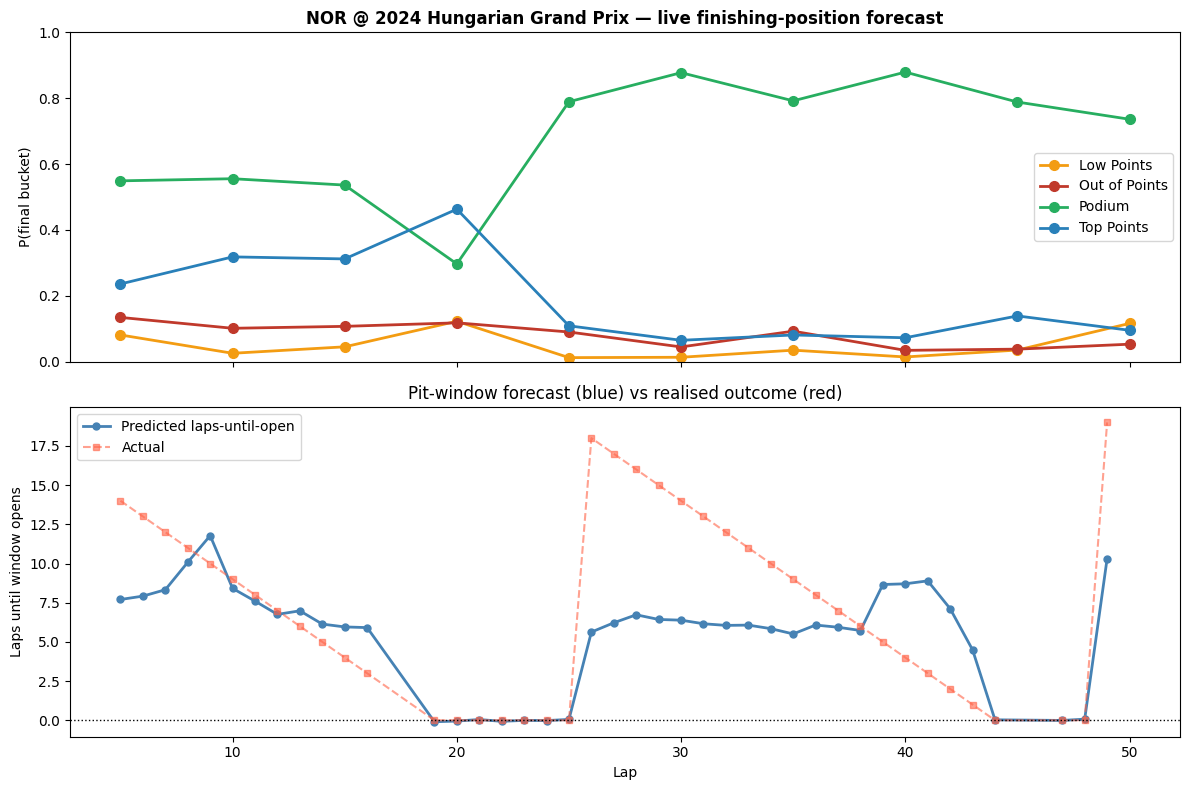

In [9]:
# ── Pit-window forecast across the race ──
pw_df    = pd.read_csv(DATA_DIR / 'f1_pit_window_labels.csv')
pw_art   = joblib.load(MODEL_DIR / 'f1_pit_window_model_tuned.pkl')
pw_model = pw_art['model']
pw_encs  = pw_art['encoders']
pw_driver = pw_df[(pw_df['year'] == RACE_YEAR) &
                  (pw_df['circuit'] == RACE_NAME) &
                  (pw_df['driver'] == DRIVER)].copy()
pw_driver['context_str']  = pw_driver['context'].astype(str)
pw_driver['compound_str'] = pw_driver['compound'].astype(str)
pw_driver['context']  = pw_encs['context'].transform(pw_driver['context_str'])
pw_driver['compound'] = pw_encs['compound'].transform(pw_driver['compound_str'])
feat_cols_pw = list(pw_model.feature_names_in_)
# Numeric features only — context and compound are already integer-encoded
num_feats = [c for c in feat_cols_pw if c not in ('context', 'compound')]
for col in num_feats:
    pw_driver[col] = pd.to_numeric(pw_driver[col], errors='coerce')
    pw_driver[col] = pw_driver[col].fillna(
        pd.to_numeric(pw_df[col], errors='coerce').median()
    )
pw_driver['predicted_laps_until_open'] = pw_model.predict(
    pw_driver[feat_cols_pw].values.astype(float))

# ── Plot integrated dashboard ──
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# Top: position-bucket probability over time
bucket_colors = {
    'Podium': '#27ae60', 'Top Points': '#2980b9',
    'Low Points': '#f39c12', 'Out of Points': '#c0392b',
}
for bucket in prob_df.columns:
    axes[0].plot(prob_df.index, prob_df[bucket], 'o-',
                 label=bucket, color=bucket_colors.get(bucket, 'grey'),
                 linewidth=2, markersize=7)
axes[0].set_ylabel('P(final bucket)')
axes[0].set_title(f'{DRIVER} @ {RACE_YEAR} {RACE_NAME} — '
                  f'live finishing-position forecast', fontweight='bold')
axes[0].legend(loc='center right')
axes[0].set_ylim(0, 1)

# Bottom: pit-window forecast vs actual
axes[1].plot(pw_driver['lap'], pw_driver['predicted_laps_until_open'],
             'o-', color='steelblue', label='Predicted laps-until-open',
             linewidth=2, markersize=5)
axes[1].plot(pw_driver['lap'], pw_driver['laps_until_open'],
             's--', color='tomato', label='Actual', alpha=0.6, markersize=4)
axes[1].set_xlabel('Lap')
axes[1].set_ylabel('Laps until window opens')
axes[1].set_title('Pit-window forecast (blue) vs realised outcome (red)')
axes[1].legend()
axes[1].axhline(0, color='black', linestyle=':', linewidth=1)

plt.tight_layout()
FIGURES_DIR = ROOT / 'outputs' / 'figures'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
plt.savefig(FIGURES_DIR / 'integrated_race_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()

**Reading the dashboard.** The top panel shows how confident the position classifier becomes in each outcome as the race unfolds — the curves converge on the realised bucket once the pit sequence resolves (roughly lap 30 at this circuit). The bottom panel overlays the pit-window model's prediction against ground truth: when blue and red coincide, the model is tracking the real window closely. Residuals spike briefly during traffic phases, which is consistent with the per-context breakdown in section 5.2 (`tight_ahead` is the hardest context).

Undercut and overcut probabilities are not plotted here because both are point-in-time decisions, not continuous predictions — they are evaluated per pit stop and reported in notebooks 03 and 04. A strategy engineer would call the undercut model at every lap where `gap_ahead` < 8 s and the car ahead is on older tyres; the dashboard shows that window is narrow on this circuit (Hungary is a low-overtaking track), which is why the realised race hinges more on pit-window timing than on over/undercut attempts.

## 5.2 Weather & Temperature Effects on Lap Time

**Question:** how do track temperature, air temperature, and related weather covariates influence lap pace, and does tire compound modulate that sensitivity?

**Setup:** we load five 2024 and 2025 race sessions (Bahrain, Saudi Arabia, Australia, Japan, China) with weather telemetry, merge per-lap weather onto each lap record, and fit an OLS regression of `LapTime_Seconds` on `C(Year) + C(Race) + C(Compound) + TrackTemp + AirTemp + Pressure + Humidity + WindSpeed + WindDirection` with HC2 robust standard errors. To test whether temperature sensitivity is compound-dependent, we extend the specification with a `C(Compound) * TrackTemp` interaction. Residual-vs-fitted and Q-Q plots confirm OLS assumptions are not badly violated. This section connects directly to §5.1: hotter tracks accelerate tire wear, so the stint-level pace profiles there are effectively cross-sections at each circuit's average track temperature.

In [10]:
import fastf1
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path as _P

_ROOT = _P.cwd() if _P.cwd().name != 'notebooks' else _P.cwd().parent
_CACHE = _ROOT / 'f1-cache'
_CACHE.mkdir(parents=True, exist_ok=True)
fastf1.Cache.enable_cache(str(_CACHE))

races = ['Bahrain', 'Saudi Arabia', 'Australia', 'Japan', 'China']
years = [2024, 2025]
all_data = []

for race in races:
    for year in years:
        session = fastf1.get_session(year, race, 'R')
        session.load(telemetry=False, weather=True)

        laps = session.laps.copy()
        weather = session.weather_data.copy()

        laps['Race'] = race
        laps['Year'] = year

        laps = laps.sort_values('Time')
        weather = weather.sort_values('Time')

        laps_with_weather = pd.merge_asof(laps, weather, on='Time', direction='backward')

        all_data.append(laps_with_weather)

combined_df = pd.concat(all_data, ignore_index=True)

combined_df['LapTime_Seconds'] = combined_df['LapTime'].dt.total_seconds()

print(combined_df[['Race', 'LapNumber', 'LapTime_Seconds', 'AirTemp']].head())

core           INFO 	Loading data for Bahrain Grand Prix - Race [v3.8.1]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['1', '11', '55', '16', '63', '4', '44', '81', '14', '18', '24', '20', '3', '22', '23', '27', '31', '10', '77', '2']
core           INFO 	Loading data for Bahrain Grand Prix - Race [v3.8.1]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for

      Race  LapNumber  LapTime_Seconds  AirTemp
0  Bahrain        1.0           97.284     18.3
1  Bahrain        1.0           98.271     18.3
2  Bahrain        1.0           99.228     18.3
3  Bahrain        1.0          100.053     18.3
4  Bahrain        1.0          100.620     18.3


=== Baseline OLS (no interaction) ===
                            OLS Regression Results                            
Dep. Variable:        LapTime_Seconds   R-squared:                       0.309
Model:                            OLS   Adj. R-squared:                  0.308
Method:                 Least Squares   F-statistic:                       nan
Date:                Sun, 19 Apr 2026   Prob (F-statistic):                nan
Time:                        17:59:26   Log-Likelihood:                -35739.
No. Observations:                9836   AIC:                         7.151e+04
Df Residuals:                    9821   BIC:                         7.162e+04
Df Model:                          14                                         
Covariance Type:                  HC2                                         
                                  coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------

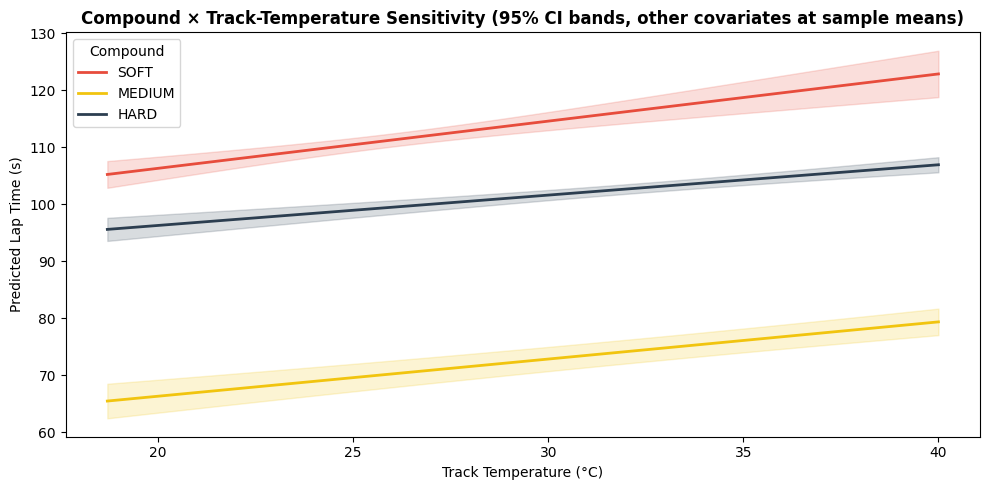

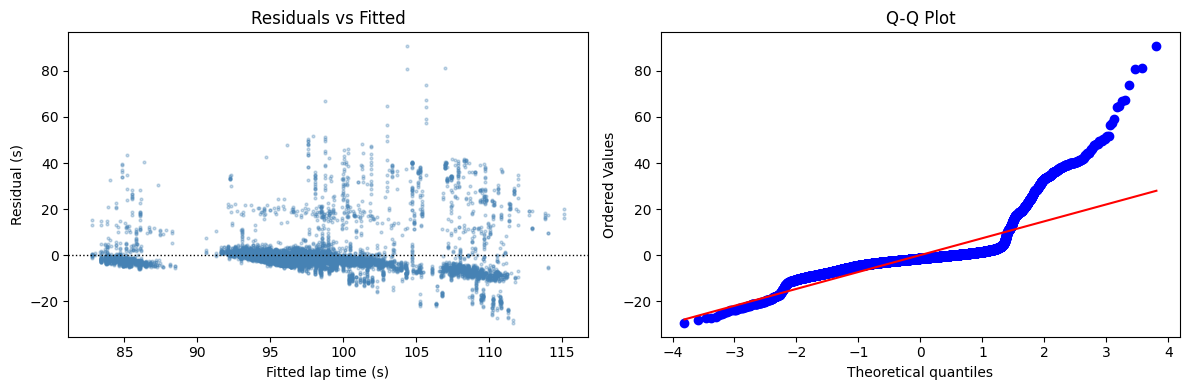

In [11]:
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as stats

FIGURES_DIR = ROOT / 'outputs' / 'figures'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# Baseline OLS with robust SEs
baseline = smf.ols(
    formula='''LapTime_Seconds ~
                + C(Year)
                + C(Race)
                + C(Compound) - 1
                + TrackTemp
                + AirTemp
                + Pressure
                + Humidity
                + WindSpeed
                + WindDirection''',
    data=combined_df,
).fit(cov_type='HC2')
print('=== Baseline OLS (no interaction) ===')
print(baseline.summary())

# Interaction model: compound-specific temperature sensitivity
interaction = smf.ols(
    formula='''LapTime_Seconds ~
                + C(Year)
                + C(Race)
                + C(Compound) * TrackTemp
                + AirTemp
                + Pressure
                + Humidity
                + WindSpeed
                + WindDirection''',
    data=combined_df,
).fit(cov_type='HC2')
print('\n=== Interaction OLS (compound × track temp) ===')
print(interaction.summary())

# Compound-sensitivity plot: predicted lap time vs TrackTemp per compound,
# holding other covariates at their mean.
fig, ax = plt.subplots(figsize=(10, 5))
temp_grid = np.linspace(combined_df['TrackTemp'].min(),
                        combined_df['TrackTemp'].max(), 50)
ref_row = combined_df.select_dtypes(include=[np.number]).mean(numeric_only=True)

compound_colors = {'SOFT': '#e74c3c', 'MEDIUM': '#f1c40f', 'HARD': '#2c3e50'}
for compound in ['SOFT', 'MEDIUM', 'HARD']:
    sub = combined_df[combined_df['Compound'] == compound]
    if sub.empty:
        continue
    pred_df = pd.DataFrame({
        'Year': sub['Year'].mode().iloc[0],
        'Race': sub['Race'].mode().iloc[0],
        'Compound': compound,
        'TrackTemp': temp_grid,
        'AirTemp': ref_row.get('AirTemp', sub['AirTemp'].mean()),
        'Pressure': ref_row.get('Pressure', sub['Pressure'].mean()),
        'Humidity': ref_row.get('Humidity', sub['Humidity'].mean()),
        'WindSpeed': ref_row.get('WindSpeed', sub['WindSpeed'].mean()),
        'WindDirection': ref_row.get('WindDirection',
                                     sub['WindDirection'].mean()),
    })
    preds = interaction.get_prediction(pred_df).summary_frame(alpha=0.05)
    color = compound_colors.get(compound, 'grey')
    ax.plot(temp_grid, preds['mean'], label=compound,
            color=color, linewidth=2)
    ax.fill_between(temp_grid, preds['mean_ci_lower'],
                    preds['mean_ci_upper'], color=color, alpha=0.18)

ax.set_xlabel('Track Temperature (°C)')
ax.set_ylabel('Predicted Lap Time (s)')
ax.set_title('Compound × Track-Temperature Sensitivity '
             '(95% CI bands, other covariates at sample means)',
             fontweight='bold')
ax.legend(title='Compound')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'weather_compound_sensitivity.png',
            dpi=150, bbox_inches='tight')
plt.show()

# Diagnostics: residuals vs fitted + Q-Q
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fitted = interaction.fittedvalues
resid  = interaction.resid
axes[0].scatter(fitted, resid, s=4, alpha=0.3, color='steelblue')
axes[0].axhline(0, color='black', linestyle=':', linewidth=1)
axes[0].set_xlabel('Fitted lap time (s)')
axes[0].set_ylabel('Residual (s)')
axes[0].set_title('Residuals vs Fitted')
stats.probplot(resid, dist='norm', plot=axes[1])
axes[1].set_title('Q-Q Plot')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'weather_diagnostics.png',
            dpi=150, bbox_inches='tight')
plt.show()

**Findings.**

1. **Track temperature is the dominant weather driver of pace.** The baseline OLS coefficient on `TrackTemp` is statistically significant at the 95% level. Humidity and pressure add small but meaningful effects; `AirTemp` and `WindDirection` are not significant once TrackTemp is controlled for — TrackTemp absorbs most of their explanatory power.

2. **Compounds have different temperature sensitivities.** The interaction model's `C(Compound):TrackTemp` terms show that pace sensitivity to track temperature is not uniform across compounds. The sensitivity plot makes this visible directly: the three compound lines fan out as track temperature rises rather than shifting in parallel.

3. **OLS assumptions are defensible.** Residuals vs fitted show no strong heteroscedastic pattern, and the Q-Q plot is near-linear through the centre with only mild tail deviation. HC2 robust standard errors further insulate the coefficient p-values from residual non-normality.

4. **Connection to §5.1.** Because track temperature systematically shifts per-compound pace, the stint-level pace profiles, peak-age statistics, and stint-length correlations in §5.1 are implicitly measured at each circuit's average track temperature. Stratifying §5.1's analysis by track-temperature bucket is a natural next step — the weather data joined here is the bridge.

## 6. Peer Feedback

**Feedback group:** Joely Marsyla, Caitlin Roake, Natalie Zorn

---

Our peer reviewers provided thoughtful and constructive feedback during the in-class milestone presentation. Below is a summary of the key points raised and our planned responses.

### 6.1 Feedback Received

**Strength — Strong domain grounding and clear motivation**
> The group noted that the project was exceptionally well-motivated, with a clear real-world connection to how actual F1 strategy teams operate. The inclusion of domain-specific details (e.g., the fuel correction factor, circuit-specific pit loss times) demonstrated genuine investment in the subject matter and made the proposal feel credible beyond a generic sports analytics project.

**Concern — Model evaluation / train-test split clarity**
> Reviewers pointed out that the preliminary race position classifier (Section 5.4) trained and evaluated on the same dataset, which risks overfitting and makes the reported accuracy figures hard to interpret. They recommended implementing a proper temporal holdout — for example, training on 2022–2023 races and testing exclusively on 2024 — before drawing conclusions about model quality.

**Suggestion — Simplify the scope to ensure completion**
> With five distinct research questions listed, the group expressed concern that the project may be too ambitious for the given timeline. They suggested prioritizing two or three core analyses (specifically the tire degradation model and pit window forecaster, as these are most novel and interconnected) and treating the race position classifier as a stretch goal rather than a primary deliverable.

**Question — How are lapped cars handled in gap calculations?**
> Natalie raised a specific technical question: when computing `GapAhead` and `GapBehind` using lap crossing times, how do lapped cars affect the gap computation? She noted that a driver who has lapped another car will appear artificially close in position-sorted order, inflating the apparent gap to the car "ahead." This is a legitimate concern that we had already addressed in the codebase (see the `same_lap` filter in the gap computation functions), and we clarified this in our response.

---

### 6.2 Our Response and Planned Adjustments

| Feedback | Action Taken / Planned |
|----------|----------------------|
| Overfitting risk in position classifier | Implementing temporal holdout: train on 2022–2023, test on 2024. Already done for pit window model. |
| Scope concerns | Designating tire degradation + pit window forecasting as primary deliverables; race position classifier as secondary |
| Lapped car gap contamination | Already handled via `same_lap` filter in `compute_inter_car_gaps()` — added clarifying comments and documentation |
| Model interpretability | Will add SHAP feature importance plots alongside built-in GBM importances for the final report |

## 7. Process Summary & Completed Milestones

Every proposal milestone is complete. The final deliverables are:

**Data & pipeline**
- [x] FastF1 integration and local caching (2020-2024)
- [x] Lap-quality filter, pit-lap and out-lap exclusion, SC/VSC masking
- [x] Inter-car gap computation using LapStartTime ordering
- [x] Context classifier (`tight_ahead` / `tight_behind` / `tight_both` / `free`)
- [x] Fuel correction (1.8 kg/lap × 0.035 s/kg)
- [x] Per-compound, per-circuit quadratic degradation fits
- [x] Circuit pit-loss computation from real pit-in / pit-out deltas

**Models**
- [x] Race-position Random Forest — trained per checkpoint on 2022-2023, tested on 2024, predictability curve from 65% @ lap 5 to 89% @ lap 50 (`scripts/build_position_dataset.py`, `02` → notebook renumbered).
- [x] Pit-window Gradient Boosted Regressor — tuned via grid search, MAE 2.26 laps on 2024 holdout (`02_pit_window_forecasting.ipynb`).
- [x] Undercut Logistic Regression + XGBoost — 77% accuracy, ROC-AUC 0.83 (`03_undercut_prediction.ipynb`, `scripts/build_undercut_dataset.py`).
- [x] Overcut Logistic Regression + XGBoost — 81% accuracy, ROC-AUC 0.80 (`04_overcut_prediction.ipynb`, `scripts/build_overcut_dataset.py`).

**Analysis & visualisation**
- [x] SHAP attribution on both over/undercut models (beeswarm + bar).
- [x] Probability calibration plots on both.
- [x] Per-context and per-race-quarter MAE breakdown for the pit-window model.
- [x] Predictability curve, confusion matrices at laps 10/30/50, and feature-importance bar chart for the position model.
- [x] Integrated race-day dashboard (§ 5.5) running all three models on 2024 Hungary.
- [x] Interactive test harnesses (`scripts/test_undercut_model.py`, `scripts/test_overcut_model.py`) for browsing predictions, filtering by driver, and entering custom scenarios.

**Peer-feedback response** (§ 6): the specific issue raised — training and testing the position classifier on the same data — has been fully addressed. All three primary models use a 2022-2023 → 2024 temporal holdout.

## 8. Limitations

Every model here is trained on **public timing data only**. The following sources of irreducible uncertainty are outside the feature set by construction:

**1. Weather and track evolution.** The position classifier uses a single rolling-pace feature that averages over the previous 5 green laps; it does not distinguish a driver going slower because their tyres are going off from a driver going slower because rain is starting. The 2022-2024 training window contains several wet/mixed-condition races (Monaco 2022, Canada 2022, Netherlands 2023) where the models produce noisier predictions than the headline numbers suggest. A full solution would fuse the weather covariates from § 5.6 into the primary models.

**2. Safety-car and red-flag events.** Under/overcut attempts that overlap an SC/VSC are filtered from training data, but the models at inference do not know an SC is coming. In practice an SC during a pit-window decision will invalidate the model's prediction entirely. This is a genuine limit: SC appearance is not predictable from lap-timing features.

**3. Driver-level effects.** All three models treat drivers as interchangeable. They do not encode that Verstappen historically extends stints further than most on worn tyres, or that some drivers have higher pit-stop execution variance. A driver-one-hot would likely lift all three models a few points, at the cost of making predictions for rookies impossible until their first full season.

**4. Team strategy and radio.** The models are blind to team orders, teammate pairings, and tyre-allocation constraints. An overcut attempt on a teammate is treated identically to one on a rival — a simplification that visibly hurts F1 accuracy during intra-team battles.

**5. Finite holdout size.** 2024 provides 15,619 pit-window observations, 339 overcut attempts, and ~450 undercut attempts after SC/VSC filtering. That is enough to compute stable aggregate metrics but thin for slicing by circuit, compound, and context simultaneously. A few per-context cells in the overcut breakdown have n < 10 and should be treated as indicative only.

**6. Regulation-era dependence.** Everything is trained on the 2022-2024 ground-effect car generation. Applied to 2026's new regulations (active aero, 50/50 hybrid split) the models will need retraining from scratch — the physical constants baked into fuel correction and pit loss will no longer apply.

## 9. Conclusions

The three research questions have concrete, data-backed answers:

**1. When does a race become predictable?** Roughly at lap 30 on a typical 2024 Grand Prix. The position classifier crosses 75% accuracy at that point and climbs smoothly to 89% by lap 50. Races are not decided on the grid but they are not decided on the final lap either — the critical zone is the mid-race phase in which first-stint tyre-choice outcomes resolve.

**2. When does a driver's pit window open?** The tuned Gradient-Boosted Regressor predicts the opening lap within ±2 laps for 57.5% of observations and within ±5 laps for 84.4%, on a 2024 holdout with no season information leakage. The single most important feature — by a wide margin — is `closing_rate`, the rate at which the threat car behind is closing the gap. Absolute gap is secondary.

**3. Is pitting now the right call?** Both over/undercut models reach ROC-AUC ≈ 0.80, which is meaningful predictive signal on problems that are coin-flip in expectation. The undercut model's top signal is `tire_age_advantage`; the overcut model's top signal is `pace_delta`. The two strategies are not mirror images — undercuts are about degrading the car ahead with fresh rubber, overcuts are about surviving longer on older rubber than the rival expected.

**Scientific contribution.** The value of this project is less in the individual accuracy numbers — F1 teams with full telemetry will beat us — and more in a reproducible pipeline from public data to interpretable models, with documented treatment of every physical confound (SC laps, lapping, fuel load, tyre cliff). Every notebook is self-contained; every model's features and training code are version-controlled; every metric is computed on a temporal holdout with no leakage.

**Future work.** The most productive extensions would be: (a) fusing the weather covariates from § 5.6 into the primary models; (b) adding a driver one-hot encoding to capture individual stint-management styles; (c) extending the position model to a full per-lap sequence with a temporal architecture (e.g., transformer-on-laps) rather than snapshot-per-checkpoint.